# Introduction to uDALES Post-processing with Python

This tutorial describes how to read and process data from the LES code uDALES using Python. This tutorial introduces the `UDBase` post-processing class.

## Overview

The **UDBase** post-processing class reads simulation parameters and contains methods to load field and facet data.

**Field data methods:**
- `load_stat_xyt`: Load 1D slab- and time-averaged statistics
- `load_stat_t`: Load 3D time-averaged statistics
- `load_field`: Load instantaneous 3D data
- `load_slice`: Load instantaneous 2D slices

**Facet data methods:**
- `calculate_frontal_properties`: Calculate skylines, frontal areas, blockage ratios
- `plot_fac_type`: Display surface types
- `assign_prop_to_fac`: Assign properties to facets
- `plot_fac`: Display variables on mesh
- `load_fac_momentum`: Load pressure and shear stresses
- `load_fac_eb`: Load energy balance terms
- `load_seb`: Load all SEB terms
- `load_fac_temperature`: Load facet temperatures
- `area_average_seb`, `area_average_fac`: Area averaging
- `time_average`: Time averaging
- `convert_fac_to_field`: Convert facet to 3D field

## 1. Import Libraries and Setup

In [ ]:
import inspect
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Add the uDALES python path
udbase_path = Path("/home/dpb24/uDALES/u-dales").resolve()
tools_path = (udbase_path / "tools" / "python").resolve()
if tools_path not in sys.path:
    sys.path.insert(0, str(tools_path))

from udbase import UDBase

# Enable interactive plots
%matplotlib inline

expnr = "201"
expdir = Path("/mnt/rds/home/uDALES/outputs/201").resolve()
sim = UDBase(expnr, expdir, backend="plotly")

# help(UDBase)

## Constructor Information

The constructor can have a number of input parameters. 

In [ ]:
print(inspect.getdoc(UDBase))
print()
print("Methods")
for name, obj in inspect.getmembers(UDBase, predicate=inspect.isfunction):
    if not name.startswith("_"):
        print(f"- {name}")

## 3. Accessing Simulation Properties

Once initialized, you can access simulation parameters and grid coordinates as properties.

In [ ]:
# To view all simulation input parameters, simply type:
sim

In [ ]:
# Access simulation properties
sim.xlen

## 4. Geometry Visualization

If a geometry file (STL) is present, UDBase automatically loads it and provides access to geometry properties and visualization capabilities.

In [ ]:
# Visualize geometry
fig = sim.geom.show()

In [ ]:
# Visualize geometry
fig = sim.geom.show_outline()

## 5. Available Methods

The UDBase class provides comprehensive methods for loading and analyzing simulation data:

**Field loading methods:**
- `load_field(var, time=None)` - Load 3D instantaneous field data
- `load_stat_xyt(var, time=None)` - Load 1D slab- and time-averaged statistics
- `load_stat_t(var)` - Load 3D time-averaged statistics
- `load_slice(slice_type, var, time=None)` - Load 2D slice data

**Facet loading methods:**
- `load_fac_momentum(time=None)` - Load momentum surface data
- `load_fac_eb(time=None)` - Load surface energy balance data
- `load_fac_temperature(time=None)` - Load facet temperature data
- `load_seb(time=None)` - Load all SEB terms

**Analysis methods:**
- `assign_prop_to_fac(prop)` - Assign properties to facets
- `area_average_fac(data, areas)` - Area-average over facets
- `area_average_seb(seb_dict, facet_type=None)` - Area-average SEB terms
- `time_average(data, axis=-1)` - Time-average data (static method)
- `convert_fac_to_field(fac_data, method='nearest')` - Convert facet to field
- `calculate_frontal_properties(direction='x')` - Calculate frontal area

**Visualization methods:**
- `plot_fac(data, building_ids=None)` - Plot facet data
- `plot_fac_type(building_ids=None)` - Plot facet types
- `plot_veg()` - Plot tree regions
- `plot_building_ids()` - Plot building IDs
- `plot_2dmap(val, labels=None)` - Plot 2D building map

In [ ]:
u = sim.load_field('u')
print(u.shape)

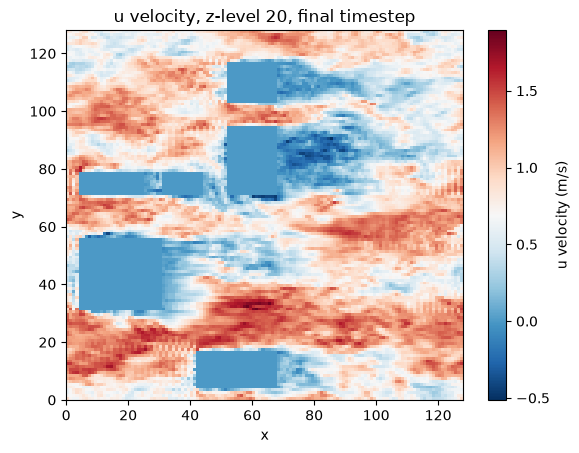

In [37]:
z_level = 20  # pick a level partway up the domain — adjust once we see the result
plt.figure()
plt.pcolormesh(u[:, :, z_level, -1].T, cmap='RdBu_r')
plt.colorbar(label='u velocity (m/s)')
plt.title(f'u velocity, z-level {z_level}, final timestep')
plt.xlabel('x')
plt.ylabel('y')
plt.show()